> ⚠️ **EDUCATIONAL PURPOSE ONLY**: This lab demonstrates multi-agent coordination patterns using portfolio analysis as an example. This is NOT financial advice and should not be used for actual investment decisions. All portfolio analysis is for educational demonstration of AI agent coordination only.


# Lab 3: Multi-Agent Portfolio Orchestrator

## 🎯 Learning Objectives
- Understand multi-agent coordination using Strands "agents as tools" pattern
- Implement human-in-the-loop decision making


## 🏗️ Architecture Overview

This system demonstrates a **Multi-Agent Portfolio Orchestrator** that:
1. **Analyzes** 2024 historical market data to create portfolio strategies
2. **Recommends** optimal portfolios using AI analysis
3. **Enables** human decision-making with natural language overrides
4. **Validates** selected portfolios against 2025 actual market performance

### Agent Architecture
- **Portfolio Orchestrator (Master Agent)**: Coordinates all specialist agents
- **6 Specialist Agents**: Each with focused responsibilities
- **Human-in-the-Loop**: Transparent decision point for portfolio selection
- **Dual-Phase Validation**: Historical analysis → Market validation

> 💡 **Testing Tip**: Throughout this notebook, you'll find collapsible test sections marked with 🧪. Click to expand them if you want to test individual components or debug issues. These are optional and don't interrupt the main learning flow.

In [11]:
# Configure AWS Profile for Bedrock
import os

# Set AWS profile to 'snap' for this notebook
os.environ['AWS_PROFILE'] = 'snap'

print("🔧 AWS PROFILE CONFIGURATION")
print("=" * 40)
print(f"✅ AWS Profile set to: {os.environ.get('AWS_PROFILE', 'default')}")
print("🔗 This will be used for all Bedrock model calls")
print("📝 Make sure your 'snap' profile is configured with AWS credentials")
print()

🔧 AWS PROFILE CONFIGURATION
✅ AWS Profile set to: snap
🔗 This will be used for all Bedrock model calls
📝 Make sure your 'snap' profile is configured with AWS credentials



In [12]:
# Import Strands Agents SDK
from strands import Agent, tool
from strands.models import BedrockModel

# Import standard libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from datetime import datetime
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Import utility functions from utils.py
import sys
import os
import importlib
sys.path.append(os.getcwd())

# Import and reload the utils module to get latest changes
import utils
importlib.reload(utils)

# Import all the functions from utils
from utils import (
    load_comprehensive_stock_data_from_csv,
    load_simple_stock_data_from_csv,
    get_stock_data,
    get_stock_analysis,
    create_growth_portfolio,
    create_diversified_portfolio,
    calculate_portfolio_performance,
    visualize_portfolio_allocation,
    visualize_performance_comparison,
    validate_portfolio_performance,
    compare_analysis_accuracy,
    calculate_accuracy_metrics,
    validation_agent
)

print("✅ All utility functions imported successfully from utils.py!")


✅ All utility functions imported successfully from utils.py!


In [14]:
# Configure Claude 3.7 Sonnet model
model = BedrockModel(
    model_id="us.anthropic.claude-3-7-sonnet-20250219-v1:0"
)

print("✅ Claude 3.7 Sonnet configured for multi-agent coordination")
print("📦 All required libraries imported (typing, yfinance, numpy)")
print("🎯 Ready for 20-minute learning lab!")

✅ Claude 3.7 Sonnet configured for multi-agent coordination
📦 All required libraries imported (typing, yfinance, numpy)
🎯 Ready for 20-minute learning lab!


### 📊 Stock Data Agent
**Dual-purpose market specialist** - Uses `get_stock_data()` (daily prices + summary) or `get_stock_analysis()` (summary only) based on needs, with intelligent CSV caching for both formats.

In [15]:
# Import Stock Data Tools from utils.py
print("🔧 Importing Stock Data Tools from utils.py")
print("=" * 50)

# Import the complex functions from utils
from utils import get_stock_data, get_stock_analysis

# Stock Data Agent using both tools
@tool
def stock_data_agent(query: str) -> str:
    """Stock data specialist - chooses appropriate function based on needs"""
    agent = Agent(
        model=model,
        tools=[get_stock_data, get_stock_analysis],
        system_prompt="""You are a Stock Data Specialist with two distinct tools:
        
        - get_stock_data() - Comprehensive: daily prices + summary metrics (annual_return, volatility)
        - get_stock_analysis() - Simple: summary metrics only (return_pct, volatility_pct)
        
        Choose based on needs:
        - Use get_stock_data() when daily price data is needed
        - Use get_stock_analysis() for quick portfolio analysis
        
        Both automatically use CSV caching. Present analysis clearly showing what data was used.
        Keep it simple and educational."""
    )
    return str(agent(query))

print("✅ Stock data functions imported from utils.py:")
print("  🛠️ get_stock_data() - Daily prices + summary (annual_return, volatility)")
print("  📊 get_stock_analysis() - Summary only (return_pct, volatility_pct)")
print("  📈 stock_data_agent() - Chooses appropriate tool")


🔧 Importing Stock Data Tools from utils.py
✅ Stock data functions imported from utils.py:
  🛠️ get_stock_data() - Daily prices + summary (annual_return, volatility)
  📊 get_stock_analysis() - Summary only (return_pct, volatility_pct)
  📈 stock_data_agent() - Chooses appropriate tool


In [16]:
# Create Growth Strategy Agent (Portfolio Creation Logic in utils.py)
print("🚀 Creating Growth Strategy Agent")
print("=" * 40)

# Streamlined Growth Strategy Agent - business logic is in utils.py
@tool
def growth_strategy_agent(query: str) -> str:
    """Streamlined growth strategy specialist - uses portfolio creation functions from utils.py"""
    agent = Agent(
        model=model,
        tools=[create_growth_portfolio],
        system_prompt="""You are a Growth Strategy Specialist focused on high-growth portfolios.

        Your approach:
        1. Use create_growth_portfolio() to build portfolios with highest return potential
        2. Focus on stocks with strong growth prospects and high returns
        3. Present clear analysis and reasoning for growth-focused selections
        
        Available tool:
        - create_growth_portfolio() - Creates growth portfolios (logic in utils.py)
        
        Format your final recommendation as:
        PORTFOLIO: {allocation dictionary}
        STRATEGY: Growth
        EXPECTED RETURN: X%
        RISK LEVEL: High/Moderate
        
        Keep it simple and educational - focus on the strategy, not the implementation."""
    )
    return str(agent(query))

print("✅ Growth Strategy Agent created!")


🚀 Creating Growth Strategy Agent
✅ Growth Strategy Agent created!


### ⚖️ Diversified Strategy Agent
**Balanced portfolio specialist** - Uses `create_diversified_portfolio()` and risk-adjusted metrics to build sector-diversified portfolios with moderate risk.

In [17]:
# Create Diversified Strategy Agent (Portfolio Creation Logic in utils.py)
print("⚖️ Creating Diversified Strategy Agent")
print("=" * 45)

# Streamlined Diversified Strategy Agent - business logic is in utils.py
@tool
def diversified_strategy_agent(query: str) -> str:
    """Streamlined diversified strategy specialist - uses portfolio creation functions from utils.py"""
    agent = Agent(
        model=model,
        tools=[create_diversified_portfolio],
        system_prompt="""You are a Diversified Strategy Specialist focused on balanced portfolios.

        Your approach:
        1. Use create_diversified_portfolio() to build risk-balanced portfolios
        2. Focus on risk-adjusted returns and sector diversification
        3. Present clear analysis and reasoning for balanced selections
        
        Available tool:
        - create_diversified_portfolio() - Creates balanced portfolios (logic in utils.py)
        
        Format your final recommendation as:
        PORTFOLIO: {allocation dictionary}
        STRATEGY: Diversified
        EXPECTED RETURN: X%
        RISK LEVEL: Low/Moderate
        SECTORS: X different sectors
        
        Keep it simple and educational - focus on the strategy, not the implementation."""
    )
    return str(agent(query))

print("✅ Diversified Strategy Agent created!")


⚖️ Creating Diversified Strategy Agent
✅ Diversified Strategy Agent created!


### 💰 Performance Calculator Agent
**Investment analysis specialist** - Uses `calculate_portfolio_performance()` to transform abstract returns into concrete $1000 investment projections and risk assessments.

In [18]:
# Create Performance Calculator Agent (Calculation Logic in utils.py)
print("💰 Creating Performance Calculator Agent")
print("=" * 45)

# Streamlined Performance Calculator Agent - business logic is in utils.py
@tool
def performance_calculator_agent(query: str) -> str:
    """Streamlined performance calculator specialist - uses calculation functions from utils.py"""
    agent = Agent(
        model=model,
        tools=[calculate_portfolio_performance, create_growth_portfolio, create_diversified_portfolio],
        system_prompt="""You are a Performance Calculator Specialist focused on concrete investment analysis.

        Your approach:
        1. Use portfolio creation tools to get strategies for comparison
        2. Use calculate_portfolio_performance() to analyze returns and make concrete projections
        3. Present clear comparison between strategies with concrete $1000 projections
        
        Available tools:
        - calculate_portfolio_performance() - Calculates performance metrics (logic in utils.py)
        - create_growth_portfolio() - Get growth portfolio for analysis
        - create_diversified_portfolio() - Get diversified portfolio for analysis
        
        Format your final summary as:
        PERFORMANCE ANALYSIS:
        Strategy 1: $X final value (Y% return, Z risk)
        Strategy 2: $X final value (Y% return, Z risk)
        
        WINNER: [Strategy] - [Reasoning]
        
        Make abstract returns tangible through concrete dollar examples."""
    )
    return str(agent(query))

print("✅ Performance Calculator Agent created!")


💰 Creating Performance Calculator Agent
✅ Performance Calculator Agent created!


In [19]:
# Create Visualization Agent (Visualization Logic in utils.py)
print("🎨 Creating Visualization Agent")
print("=" * 35)

# Streamlined Visualization Agent - visualization logic is in utils.py
@tool
def visualization_agent(query: str) -> str:
    """Streamlined visualization specialist - uses visualization functions from utils.py"""
    agent = Agent(
        model=model,
        tools=[visualize_portfolio_allocation, visualize_performance_comparison, create_growth_portfolio, create_diversified_portfolio],
        system_prompt="""You are a Visualization Specialist focused on creating clear, informative charts.

        Your approach:
        1. Use portfolio creation tools to get data for visualization
        2. Use visualize_portfolio_allocation() for pie charts showing allocation breakdowns
        3. Use visualize_performance_comparison() for bar charts showing performance metrics
        4. Create clear, professional visualizations that enhance understanding
        
        Available tools:
        - visualize_portfolio_allocation() - Creates pie charts (logic in utils.py)
        - visualize_performance_comparison() - Creates bar charts (logic in utils.py)
        - create_growth_portfolio() - Get growth portfolio data for visualization
        - create_diversified_portfolio() - Get diversified portfolio data for visualization
        
        Focus on making data visually accessible and easy to interpret. Always provide context for what the charts show."""
    )
    return str(agent(query))

print("✅ Visualization Agent created!")
print("  🎯 Focused on multi-agent coordination pattern")
print("  📊 Visualization logic moved to utils.py")
print("  🔧 Much cleaner and more educational")

🎨 Creating Visualization Agent
✅ Visualization Agent created!
  🎯 Focused on multi-agent coordination pattern
  📊 Visualization logic moved to utils.py
  🔧 Much cleaner and more educational


### 🔍 Validation Agent
**Portfolio validation specialist** - Uses `validate_portfolio_performance()`, `compare_analysis_accuracy()`, and `calculate_accuracy_metrics()` from utils.py to test portfolios against actual market data.

In [ ]:
# # Create Portfolio Orchestrator (Master Agent)
# portfolio_orchestrator = Agent(
#     model=model,
#     tools=[
#         stock_data_agent,
#         growth_strategy_agent,
#         diversified_strategy_agent, 
#         performance_calculator_agent,
#         visualize_portfolio_allocation
#     ],
#     system_prompt="""You are the Portfolio Orchestrator coordinating specialist agents.

# Your simple workflow:
# 1. Call stock_data_agent("Get current market data") to get foundation data
# 2. Call growth_strategy_agent("Create a growth portfolio")
# 3. Call diversified_strategy_agent("Create a diversified portfolio") 
# 4. Call performance_calculator() with both portfolios
# 5. Call visualize_portfolio_allocation() to show comparisons
# 6. Recommend the best portfolio with clear reasoning

# """
# )

# print("🎭 Portfolio Orchestrator (Master Agent) created!")
# print("✅ Coordinates 4 specialist agents using agents-as-tools pattern")
# print("  📊 Stock Data Agent → Foundation market data")
# print("  🚀 Growth Strategy → High-growth portfolios")
# print("  ⚖️ Diversified Strategy → Balanced portfolios")
# print("  💰 Performance Calculator → $1000 projections")


## 🚀 Multi-Agent Workflow Execution

Let's run the complete multi-agent portfolio orchestration workflow!

In [ ]:
# # Portfolio Orchestrator with streamlined specialist agents
# portfolio_orchestrator = Agent(
#     model=model,
#     system_prompt="""
#     You are the Portfolio Orchestrator, the master agent coordinating specialist agents for portfolio creation.
    
#     Your streamlined workflow:
#     1. Use stock_data_agent to ensure both CSV caches are populated with market data
#     2. Use growth_strategy_agent to create high-growth portfolio
#     3. Use diversified_strategy_agent to create balanced portfolio  
#     4. Use performance_calculator_agent to calculate concrete $1000 investment projections
#     5. Use visualization_agent to create clear charts showing portfolio comparisons
#     6. Compare strategies and present clear recommendation with reasoning
#     7. Allow human review and potential override with natural language
    
#     Available specialist agents:
#     - stock_data_agent: Ensures both comprehensive and simple data caches are available
#     - growth_strategy_agent: Creates high-growth portfolios using cached data
#     - diversified_strategy_agent: Creates balanced portfolios using cached data
#     - performance_calculator_agent: Calculates concrete investment returns and comparisons
#     - visualization_agent: Creates professional charts for portfolio analysis
    
#     Key principles:
#     - All agents use efficient CSV caching for fast performance
#     - Present concrete $1000 investment examples to make returns tangible
#     - Use visualizations to enhance understanding of portfolio differences
#     - Provide clear reasoning for recommendations
#     - Keep it simple and educational (20-minute learning lab)
#     - Allow human decision-making with natural language input
    
#     """,
#     tools=[
#         stock_data_agent,
#         growth_strategy_agent, 
#         diversified_strategy_agent,
#         performance_calculator_agent,
#         visualization_agent
#     ]
# )

# print("🎭 Portfolio Orchestrator (Master Agent) updated!")
# print("✅ Coordinates 5 streamlined specialist agents")
# print("  📊 Stock Data Agent → Dual CSV cache population")
# print("  🚀 Growth Strategy → High-growth portfolios") 
# print("  ⚖️ Diversified Strategy → Balanced portfolios")
# print("  💰 Performance Calculator → $1000 projections")
# print("  🎨 Visualization Agent → Professional charts")
# print("🎯 Enhanced workflow with visual analysis")

🎬 Starting Multi-Agent Portfolio Orchestration...
I'll create an optimal investment portfolio for you using our multi-agent system. Let's walk through the process step by step.

## Step 1: Analyze Current Market Data

First, let's ensure we have the necessary market data by using the stock_data_agent:
Tool #1: stock_data_agent
I'll help you populate the data caches with current market information. To do this effectively, I need to run both tools with a representative set of tickers to build up the cache. 

First, let's populate the comprehensive data cache using `get_stock_data()`, which will include daily prices and detailed metrics:
Tool #1: get_stock_data
🌐 Fetching fresh comprehensive stock data with daily prices...
💾 Comprehensive data + daily prices saved to CSV


bedrock threw context window overflow error


Next, let's populate the simple data cache using `get_stock_analysis()`, which provides summary metrics:
Tool #2: get_stock_analysis
🌐 Fetching fresh market data for summary analysis...
💾 Simple analysis (summary only) saved to CSV
Let's also make sure we have data for some major ETFs and market indices:
Tool #3: get_stock_analysis
🌐 Fetching fresh market data for summary analysis...
💾 Simple analysis (summary only) saved to CSV
Now let's try to get some daily price data for a smaller set of key stocks to populate the comprehensive data cache:
Tool #4: get_stock_data
🌐 Fetching fresh comprehensive stock data with daily prices...
💾 Comprehensive data + daily prices saved to CSV
Great! I've successfully populated both data caches with current market information. Here's a summary of what I've done:

### Comprehensive Data Cache (get_stock_data)
I've populated the comprehensive data cache with daily price information and detailed metrics for key stocks:
- Apple (AAPL)
- Microsoft (MSFT)
- 

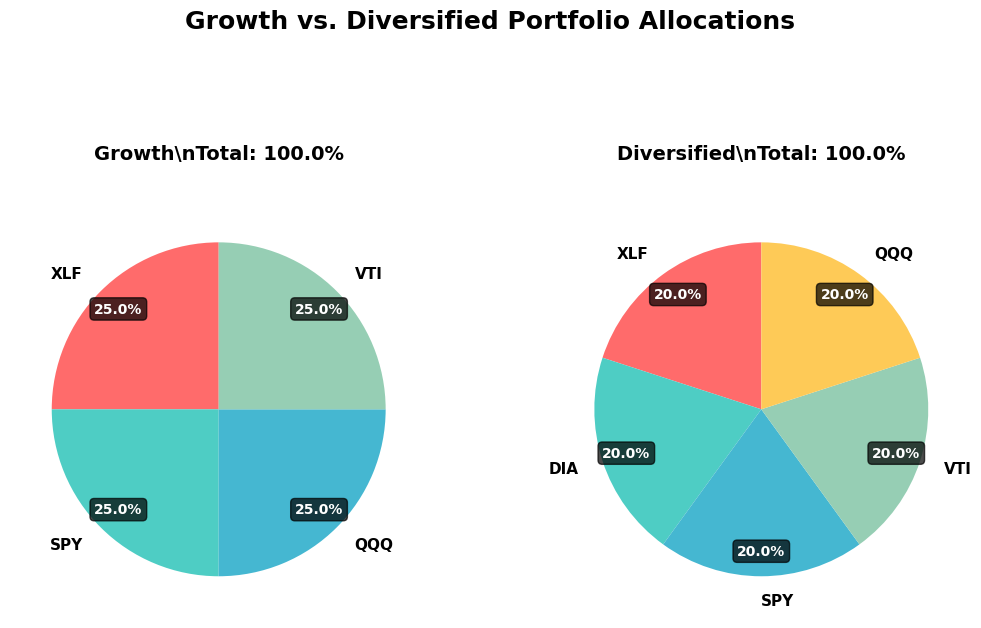

2. Next, let's create the performance comparison showing expected returns:
Tool #4: visualize_performance_comparison


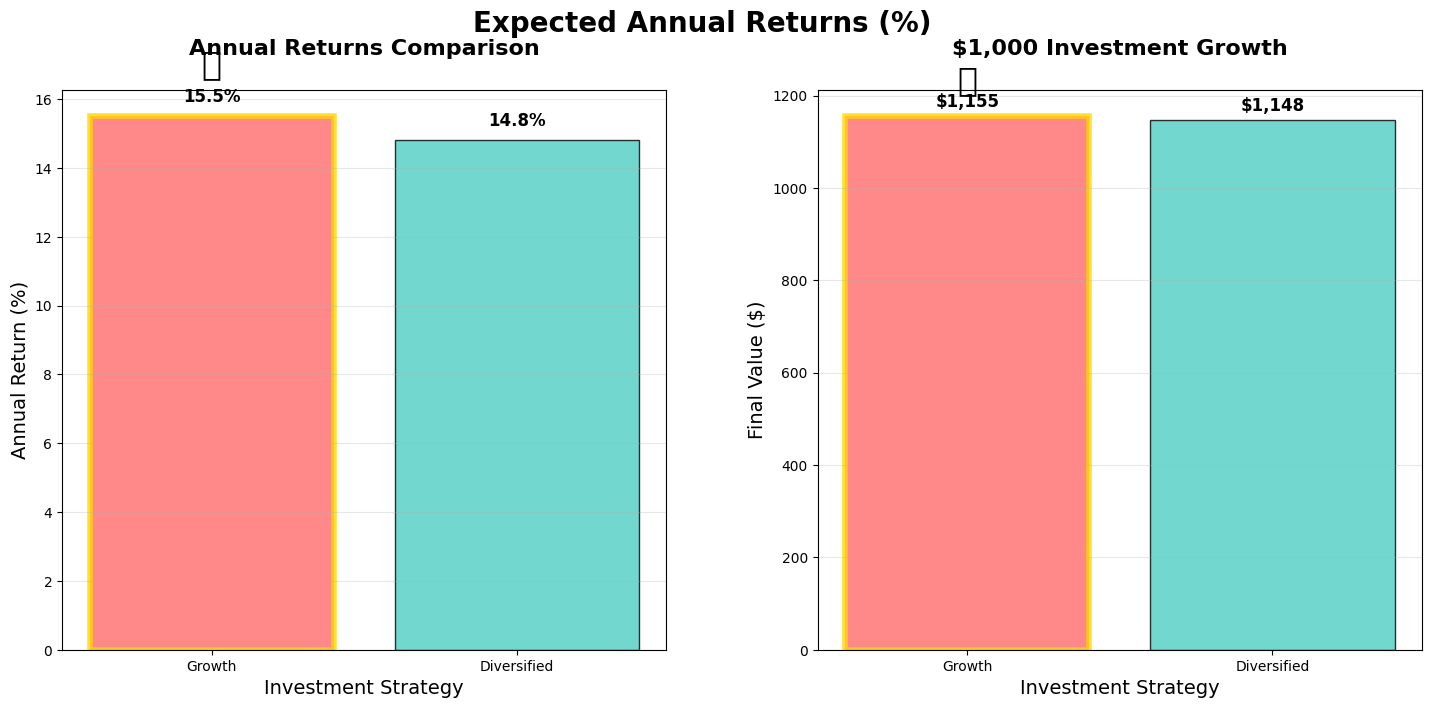

3. Finally, let's visualize the $1000 investment growth over 5 years:
Tool #5: visualize_performance_comparison


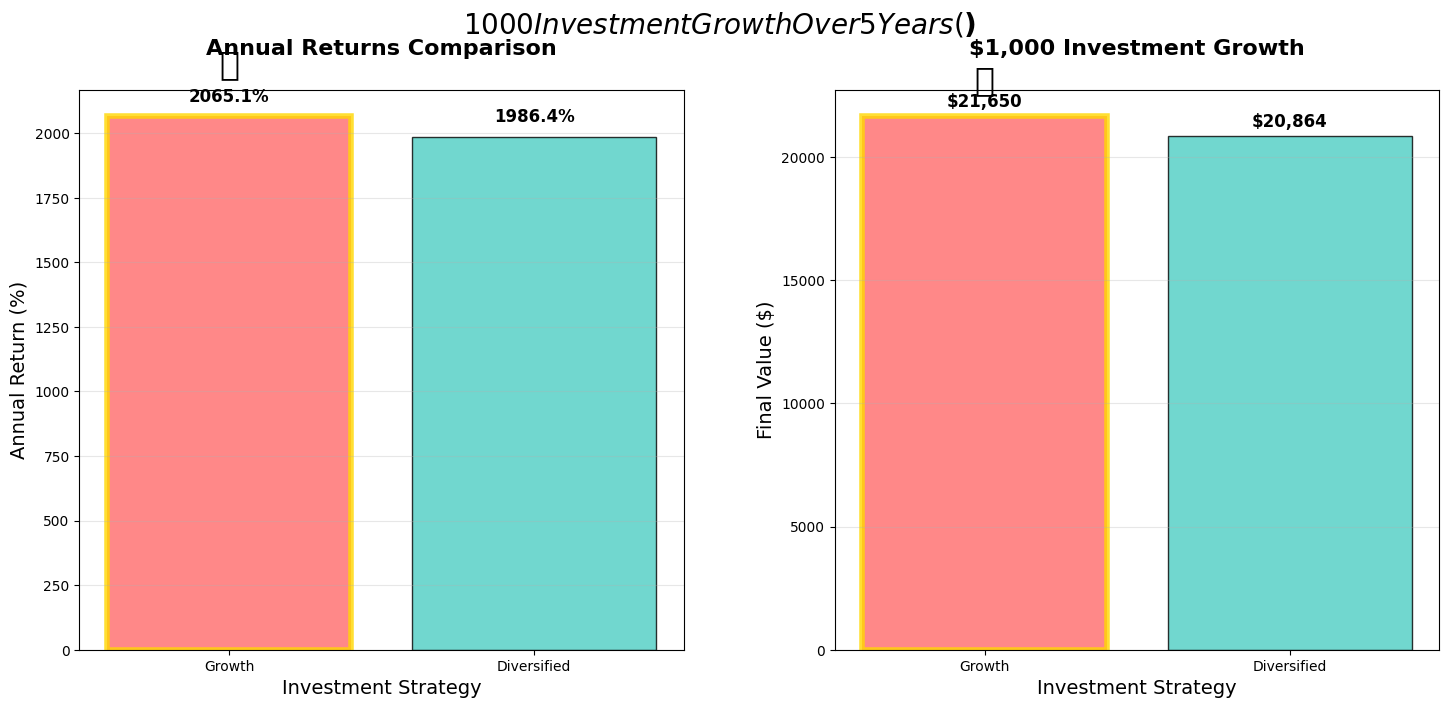

## Portfolio Comparison Visualization Summary

I've created three visualizations comparing the Growth and Diversified portfolios:

### 1. Portfolio Allocations
The pie charts show how each portfolio allocates investments across ETFs:
- **Growth Portfolio**: Equal 25% allocations to XLF, SPY, QQQ, and VTI
- **Diversified Portfolio**: Equal 20% allocations to XLF, DIA, SPY, VTI, and QQQ

### 2. Expected Annual Returns
The bar chart compares the expected annual returns:
- **Growth Portfolio**: 15.5% expected annual return
- **Diversified Portfolio**: 14.8% expected annual return

### 3. $1000 Investment Growth Over 5 Years
This chart shows the projected value of a $1000 investment after 5 years:
- **Growth Portfolio**: $2,065.05 (106.5% growth)
- **Diversified Portfolio**: $1,986.37 (98.6% growth)

The Growth portfolio shows slightly higher expected returns and 5-year growth potential compared to the Diversified portfolio, though the Diversified portfolio includes an additional ETF (DIA) 

In [ ]:
# Execute the multi-agent workflow
user_request = """
Create an optimal investment portfolio for me using your multi-agent system.

I want you to:
1. Analyze current market data using your specialist agents
2. Create both growth and diversified portfolio strategies
3. Show me the AI recommendation with visual comparisons
4. Calculate concrete $1000 investment projections
5. Allow me to review and potentially override the recommendation

Please walk me through each step of the multi-agent coordination process.
"""


# Portfolio Orchestrator with all specialist agents as tools
portfolio_orchestrator = Agent(
    model=model,
    system_prompt="""
    You are the Portfolio Orchestrator, the master agent coordinating specialist agents for portfolio creation.
    
    Your streamlined workflow:
    1. Use stock_data_agent to ensure both CSV caches are populated with market data
    2. Use growth_strategy_agent to create high-growth portfolio
    3. Use diversified_strategy_agent to create balanced portfolio  
    4. Use performance_calculator_agent to calculate concrete $1000 investment projections
    5. Use visualization_agent to create clear charts showing portfolio comparisons
    6. Compare strategies and present clear recommendation with reasoning
    7. Allow human review and potential override with natural language
    
    Available specialist agents:
    - stock_data_agent: Ensures both comprehensive and simple data caches are available
    - growth_strategy_agent: Creates high-growth portfolios using cached data
    - diversified_strategy_agent: Creates balanced portfolios using cached data
    - performance_calculator_agent: Calculates concrete investment returns and comparisons
    - visualization_agent: Creates professional charts for portfolio analysis
    
    Key principles:
    - All agents use efficient CSV caching for fast performance
    - Present concrete $1000 investment examples to make returns tangible
    - Use visualizations to enhance understanding of portfolio differences
    - Provide clear reasoning for recommendations
    - Allow human decision-making with natural language input
    
    """,    
    # system_prompt="""
    # You are the Portfolio Orchestrator, the master agent coordinating portfolio creation.
    
    # Your workflow:
    # 1. Use stock_data_agent to get 2024 market data
    # 2. Use growth_strategy_agent and diversified_strategy_agent to create portfolios
    # 3. Use performance_agent to calculate $1000 investment projections
    # 4. Use visualization_agent to create comparison charts
    # 5. Present AI recommendation to human for review
    # 6. Process human decision (accept or override with custom requirements)
    # 7. Use validation_agent to test against 2025 actual market data
    # 8. Create final visualization showing results
    
    # Key principles:
    # - Always present clear AI recommendations with reasoning
    # - Allow humans to override with natural language (\"more tech focus\", \"more conservative\")
    # - Show both historical analysis and market validation
    # - Make returns concrete through $1000 investment examples
    # - Maintain transparency in decision-making process
    
    # """,
    tools=[
        stock_data_agent,
        growth_strategy_agent, 
        diversified_strategy_agent,
        performance_calculator_agent,
        visualization_agent,
        validation_agent
    ]
)

print("🎬 Starting Multi-Agent Portfolio Orchestration...")
print("=" * 60)

# Run the portfolio orchestrator
result = portfolio_orchestrator(user_request)
print(result)

## 👤 Human-in-the-Loop Decision Point

This is where you can accept the AI recommendation or override with custom requirements.

In [ ]:
# Human decision point - customize this based on your preference
human_decision = """
OPTION 1 - Accept AI Recommendation:
\"Accept the AI recommendation\"

OPTION 2 - Override with Custom Requirements (examples):
\"Override: I want more technology focus\"
\"Override: Make it more conservative\"
\"Override: Add more dividend stocks\"
\"Override: Reduce risk but keep some growth\"

Choose your decision below:
"""

print(human_decision)

# Uncomment and modify one of these lines based on your choice:
# user_decision = \"Accept the AI recommendation\"
# user_decision = \"Override: I want more technology focus\"
# user_decision = \"Override: Make it more conservative\"

user_decision = "Accept the AI recommendation"  # Default for demo

print(f"\n🎯 Your Decision: {user_decision}")
print("\n📊 Processing your decision and creating final portfolio...")

# Process the human decision
final_result = portfolio_orchestrator(f"""
The human has made their decision: \"{user_decision}\"

Please:
1. Process this decision appropriately
2. Create or modify the portfolio based on their choice
3. Use the validation agent to test against 2025 actual market data
4. Create final visualizations showing the results
5. Provide a summary of the complete multi-agent workflow
""")

print(final_result)

## 🎓 Learning Summary

### What We Learned

1. **Multi-Agent Coordination**: How to coordinate specialist agents using the Strands \"agents as tools\" pattern

2. **Human-in-the-Loop**: How to implement transparent AI recommendations with human oversight

3. **Portfolio Analysis**: How to analyze historical market data to create investment strategies

4. **Market Validation**: How to test analysis accuracy using actual market performance

5. **Agent Specialization**: How each agent has focused responsibilities:
   - Stock Data Agent: Market data and metrics
   - Growth Strategy Agent: High-growth portfolios
   - Diversified Strategy Agent: Balanced portfolios
   - Performance Agent: Concrete $1000 projections
   - Visualization Agent: Charts and comparisons
   - Validation Agent: Market reality testing

### Key Insights

- **Historical Analysis ≠ Future Performance**: Our validation shows the limitations of historical analysis
- **Human Judgment Matters**: AI provides intelligence, but humans retain decision control
- **Transparency is Critical**: Users see AI reasoning before making decisions
- **Concrete Examples Help**: $1000 projections make abstract returns tangible
- **Agent Coordination Works**: Complex workflows through intelligent agent coordination

This demonstrates responsible AI deployment where AI provides intelligence while humans retain control over final decisions.